# **MODELO 2: CLASIFICACIÓN DEL PORCENTAJE DE BECA**

Este notebook desarrolla un modelo de clasificación multiclase para predecir el rango de porcentaje de beca asignado (baja, media, alta o máxima), utilizando el df_model solo con beneficiarios de becas

# Preparación del dataset

Se limpia y normaliza la variable de porcentaje, se convierten los valores en categorías y se construye el df_model específico para esta tarea.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score


In [ ]:
file_path = "/content/df_model_final_Aprob"

# Cargar el dataset
df = pd.read_excel(file_path)

# Vista rápida
print("Dimensiones del dataset:", df.shape)
print("\nColumnas disponibles:")
print(df.columns.tolist())

# Conteo de valores nulos
print("\nValores nulos por columna:")
print(df.isna().sum())

# Balance de clases en la variable objetivo
print("\nDistribución de la variable '% beca talento final aprobada':")
print(df["% beca talento final aprobada"].value_counts(normalize=True) * 100)

Dimensiones del dataset: (2074, 18)

Columnas disponibles:
['ID_anon', 'Resultado Final', 'puntos_academicos_int', 'Pregrado al que aspiras', 'Estado de matricula', '% beca talento final aprobada', 'Entrevista', 'paso_entrevista', 'Ensayo', 'paso_ensayo', 'dependencia_economica', 'Padres_profesionales', 'log_ingresos_padres', 'puntos_estrato', 'analisis_economico', 'Edad al postularse', 'Sexo biológico', 'Dpto de Residencia']

Valores nulos por columna:
ID_anon                          0
Resultado Final                  0
puntos_academicos_int            0
Pregrado al que aspiras          0
Estado de matricula              0
% beca talento final aprobada    0
Entrevista                       0
paso_entrevista                  0
Ensayo                           0
paso_ensayo                      0
dependencia_economica            0
Padres_profesionales             0
log_ingresos_padres              0
puntos_estrato                   0
analisis_economico               0
Edad al postulars

# Análisis de la distribución de clases

Se revisa el balance de los niveles de beca creados y se identifican posibles desbalances entre categorías que pueden afectar el rendimiento del modelo.

In [ ]:
df['% beca talento final aprobada'].value_counts(dropna=False)


,count
% beca talento final aprobada,
0.4,894
0.5,421
0.6,234
0.7,224
0.8,148
1.0,139
0.2,14


In [ ]:
target_col = '% beca talento final aprobada'

# Revisar algunos valores
print("Primeros valores del target:")
print(df[target_col].head(5))

print("\nDescripción estadística:")
print(df[target_col].describe())




Primeros valores del target:
0    0.7
1    0.8
2    0.6
3    0.4
4    0.4
Name: % beca talento final aprobada, dtype: float64

Descripción estadística:
count    2074.000000
mean        0.542671
std         0.178153
min         0.200000
25%         0.400000
50%         0.500000
75%         0.600000
max         1.000000
Name: % beca talento final aprobada, dtype: float64


In [ ]:
target_col = '% beca talento final aprobada'

serie = df[target_col]

# 1. Normalizar a porcentajes enteros
if serie.dropna().between(0, 1).all():
    df[target_col] = (serie * 100).round()
else:
    df[target_col] = serie.round()

df[target_col] = df[target_col].astype(float)

# 2. Definir buckets
def bucket_beca(p):
    if p <= 40:
        return "Baja (<=40%)"
    elif p <= 60:
        return "Media (50-60%)"
    elif p <= 80:
        return "Alta (70-80%)"
    else:
        return "Máxima (100%)"

df[target_col] = df[target_col].apply(bucket_beca)

print("Distribución de buckets:")
print(df[target_col].value_counts(normalize=True) * 100)



Distribución de buckets:
% beca talento final aprobada
Baja (<=40%)      43.780135
Media (50-60%)    31.581485
Alta (70-80%)     17.936355
Máxima (100%)      6.702025
Name: proportion, dtype: float64


In [ ]:
y = df[target_col]


In [ ]:
# Columnas que NO queremos usar como predictores
columnas_a_excluir = ['ID_anon', 'Estado de matricula', target_col]

# Features
X = df.drop(columns=columnas_a_excluir)

# Target como clases (ya viene como str)
y = df[target_col]

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Ejemplo de y:", y.unique())


Shape X: (2074, 15)
Shape y: (2074,)
Ejemplo de y: ['Alta (70-80%)' 'Media (50-60%)' 'Baja (<=40%)' 'Máxima (100%)']


# Preprocesamiento y codificación

Se separan variables numéricas y categóricas, se aplican transformaciones como estandarización y one-hot encoding, y se deja el dataset listo para el entrenamiento de modelos multiclase.

In [ ]:
# Identificar tipos de variables
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Variables categóricas:", cat_cols)
print("Variables numéricas:", num_cols)

Variables categóricas: ['Resultado Final', 'Pregrado al que aspiras', 'Sexo biológico', 'Dpto de Residencia']
Variables numéricas: ['puntos_academicos_int', 'Entrevista', 'paso_entrevista', 'Ensayo', 'paso_ensayo', 'dependencia_economica', 'Padres_profesionales', 'log_ingresos_padres', 'puntos_estrato', 'analisis_economico', 'Edad al postularse']


In [ ]:
# Transformación para columnas numéricas
numeric_transformer = StandardScaler()

# Transformación para columnas categóricas
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Combinamos en un solo preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Random Forest (modelo base)

Se entrena un Random Forest con sobremuestreo para manejar el desbalance. Se presentan sus métricas de desempeño y la matriz de confusión.

In [ ]:
!pip install imblearn

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline


In [ ]:
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

pipe = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('oversample', RandomOverSampler(random_state=42)),
    ('model', clf)
])


In [ ]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['puntos_academicos_int',
                                                   'Entrevista',
                                                   'paso_entrevista', 'Ensayo',
                                                   'paso_ensayo',
                                                   'dependencia_economica',
                                                   'Padres_profesionales',
                                                   'log_ingresos_padres',
                                                   'puntos_estrato',
                                                   'analisis_economico',
                                                   'Edad al postularse']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Resultado Final',
                                                   'Pregrado al que aspiras',
                                                   'Sexo biológico',
                                                   'Dpto de Residencia'])])),
                ('oversample', RandomOverSampler(random_state=42)),
                ('model',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred = pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:", f1_score(y_test, y_pred, average='macro'))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.619277108433735
F1 macro: 0.5013249368406635

Reporte de clasificación:

                precision    recall  f1-score   support

 Alta (70-80%)       0.44      0.61      0.51        74
  Baja (<=40%)       0.82      0.75      0.78       182
Media (50-60%)       0.52      0.56      0.54       131
 Máxima (100%)       0.50      0.11      0.18        28

      accuracy                           0.62       415
     macro avg       0.57      0.50      0.50       415
  weighted avg       0.64      0.62      0.62       415



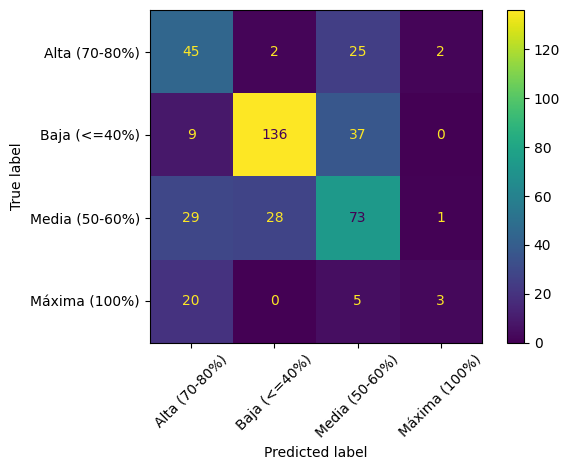

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=4,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor F1 macro (cv):", grid.best_score_)

# Re-evaluar en test con el mejor modelo
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("\nF1 macro en test:", f1_score(y_test, y_pred_best, average='macro'))
print("\nReporte de clasificación (mejor modelo):\n")
print(classification_report(y_test, y_pred_best))


Mejores parámetros: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 300}
Mejor F1 macro (cv): 0.5476936492472639

F1 macro en test: 0.5106708262135617

Reporte de clasificación (mejor modelo):

                precision    recall  f1-score   support

 Alta (70-80%)       0.45      0.51      0.48        74
  Baja (<=40%)       0.83      0.71      0.77       182
Media (50-60%)       0.53      0.56      0.54       131
 Máxima (100%)       0.23      0.29      0.25        28

      accuracy                           0.60       415
     macro avg       0.51      0.52      0.51       415
  weighted avg       0.63      0.60      0.61       415



In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # etiquetas codificadas 0..K-1
y_test_enc  = le.transform(y_test)

print("Clases originales:", le.classes_)
print("Ejemplo y_train_enc:", np.unique(y_train_enc))


Clases originales: ['Alta (70-80%)' 'Baja (<=40%)' 'Media (50-60%)' 'Máxima (100%)']
Ejemplo y_train_enc: [0 1 2 3]


# Entrenamiento de modelos base

Se definen los modelos base utilizados para la clasificación multiclase. XGBoost y CatBoost permiten modelar interacciones complejas y variables categóricas de forma eficiente, mientras que Balanced Random Forest y ExtraTrees aportan estabilidad y robustez ante el desbalance entre niveles de beca. Estos modelos sirven como referencia inicial para comparar desempeño antes del proceso de optimización.

In [ ]:
!pip install catboost xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.5 MB/s eta 0:00:00


In [ ]:
# Identificar columnas categóricas (object)
cat_cols = X_train.select_dtypes(include=['object']).columns

# Índices de esas columnas dentro del DataFrame X_train
cat_cols_idx = [X_train.columns.get_loc(c) for c in cat_cols]


In [ ]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

modelos_base = {
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        num_class=len(le.classes_),
        eval_metric="mlogloss",
        learning_rate=0.05,
        n_estimators=400,
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        loss_function="MultiClass",
        random_seed=42,
        verbose=0
    ),

    "BalancedRF": BalancedRandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=400,
        random_state=42
    )
}



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

resultados = []

for nombre, modelo in modelos_base.items():

    if nombre == "CatBoost":
        modelo.fit(X_train, y_train_enc, cat_features=cat_cols_idx)
        y_pred = modelo.predict(X_test)

    else:
        pipe_clf = Pipeline([
            ("preprocess", preprocessor),
            ("model", modelo)
        ])
        pipe_clf.fit(X_train, y_train_enc)
        y_pred = pipe_clf.predict(X_test)

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test_enc, y_pred),
        "F1_macro": f1_score(y_test_enc, y_pred, average='macro'),
        "Recall_macro": recall_score(y_test_enc, y_pred, average='macro'),
        "Precision_macro": precision_score(y_test_enc, y_pred, average='macro')
    })

pd.DataFrame(resultados).sort_values("F1_macro", ascending=False)


,Modelo,Accuracy,F1_macro,Recall_macro,Precision_macro
1,CatBoost,0.628916,0.540808,0.527484,0.631394
0,XGBoost,0.631325,0.523515,0.513418,0.572288
2,BalancedRF,0.592771,0.493745,0.497926,0.495970
3,ExtraTrees,0.578313,0.435261,0.441617,0.489916


# Optimización con GridSearch

Se realiza búsqueda de hiperparámetros para mejorar el rendimiento de los modelos seleccionados y evaluar si la optimización incrementa la capacidad de clasificación por rangos.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from catboost import Pool

In [ ]:
# MODELOS BASE

modelos = {
    "CatBoost": CatBoostClassifier(
        loss_function="MultiClass",
        random_seed=42,
        verbose=False
    ),
    "XGBoost": XGBClassifier(
        objective="multi:softmax",
        num_class=len(le.classes_),
        eval_metric="mlogloss"
    ),
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "LogReg": LogisticRegression(
        max_iter=4000,
        multi_class="multinomial",
        random_state=42
    )
}

# HIPERPARÁMETROS PARA CADA MODELO


param_grids = {
    "CatBoost": {
        "iterations": [300, 600],
        "depth": [4, 6, 8],
        "learning_rate": [0.03, 0.05]
    },

    "XGBoost": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [4, 6],
        "model__learning_rate": [0.05, 0.1]
    },

    "RandomForest": {
        "model__n_estimators": [200, 500],
        "model__max_depth": [6, 12],
        "model__criterion": ["gini", "entropy"]
    },

    "GradientBoosting": {
        "model__n_estimators": [200, 400],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 5]
    },

    "LogReg": {
        "model__C": [0.1, 1, 10],
        "model__solver": ["lbfgs"]
    }
}


# GRIDSEARCH PARA CADA MODELO

resultados_gs = []

for nombre, modelo in modelos.items():
    print(f"\n➡ GridSearch para: {nombre}")

    if nombre == "CatBoost":
        # CatBoost NO usa Pipeline ni OneHotEncoder
        train_pool = Pool(X_train, y_train_enc, cat_features=cat_cols_idx)
        test_pool = Pool(X_test, y_test_enc, cat_features=cat_cols_idx)

        modelo.grid_search(
            param_grid=param_grids["CatBoost"],
            X=train_pool,
            cv=3,
            verbose=1,
            refit=True
        )

        y_pred = modelo.predict(X_test)

    else:
        # Modelos normales usando pipeline
        pipe = Pipeline([
            ("preprocess", preprocessor),
            ("model", modelo)
        ])

        grid = GridSearchCV(
            estimator=pipe,
            param_grid=param_grids[nombre],
            scoring="f1_macro",
            cv=3,
            n_jobs=-1,
            verbose=1
        )

        grid.fit(X_train, y_train_enc)
        best_estimator = grid.best_estimator_
        y_pred = best_estimator.predict(X_test)

    # Guardar resultados
    resultados_gs.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test_enc, y_pred),
        "F1_macro": f1_score(y_test_enc, y_pred, average='macro'),
        "Precision_macro": precision_score(y_test_enc, y_pred, average='macro', zero_division=0),
        "Recall_macro": recall_score(y_test_enc, y_pred, average='macro', zero_division=0)
    })

# Mostrar tabla final
df_grid_results = pd.DataFrame(resultados_gs).sort_values("F1_macro", ascending=False)
df_grid_results



➡ GridSearch para: CatBoost

bestTest = 0.8144186905
bestIteration = 299

0:	loss: 0.8144187	best: 0.8144187 (0)	total: 2.24s	remaining: 24.7s

bestTest = 0.80279075
bestIteration = 299

1:	loss: 0.8027907	best: 0.8027907 (1)	total: 4.51s	remaining: 22.6s

bestTest = 0.8033217691
bestIteration = 587

2:	loss: 0.8033218	best: 0.8027907 (1)	total: 11s	remaining: 33s

bestTest = 0.8021276005
bestIteration = 325

3:	loss: 0.8021276	best: 0.8021276 (3)	total: 18.7s	remaining: 37.3s

bestTest = 0.8115479124
bestIteration = 299

4:	loss: 0.8115479	best: 0.8021276 (3)	total: 24.1s	remaining: 33.8s

bestTest = 0.8123015222
bestIteration = 282

5:	loss: 0.8123015	best: 0.8021276 (3)	total: 29.7s	remaining: 29.7s

bestTest = 0.802794967
bestIteration = 528

6:	loss: 0.8027950	best: 0.8021276 (3)	total: 35s	remaining: 25s

bestTest = 0.8123015222
bestIteration = 282

7:	loss: 0.8123015	best: 0.8021276 (3)	total: 41.4s	remaining: 20.7s

bestTest = 0.8214780382
bestIteration = 284

8:	loss: 0.82147

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,Modelo,Accuracy,F1_macro,Precision_macro,Recall_macro
0,CatBoost,0.648193,0.545793,0.638167,0.537067
1,XGBoost,0.638554,0.531512,0.590150,0.523019
3,GradientBoosting,0.607229,0.508846,0.548869,0.498949
2,RandomForest,0.626506,0.477365,0.694881,0.486600
4,LogReg,0.585542,0.455699,0.490273,0.451093


# Interpretación y resultados finales

Se presenta la comparación general de todos los modelos, destacando cuál ofrece el mejor desempeño para predecir el porcentaje de beca y qué categorías resultan más difíciles de clasificar. El mejor modelo es CatBoost

In [ ]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

resultados_gs = []
best_catboost = None

for nombre, modelo in modelos.items():
    print(f"\n➡ GridSearch para: {nombre}")

    if nombre == "CatBoost":
        # 1. Re-instanciamos CatBoost (modelo "limpio", sin entrenar)
        cat_model = CatBoostClassifier(
            loss_function="MultiClass",
            random_seed=42,
            verbose=False
        )

        # 2. Pools con variables categóricas
        train_pool = Pool(X_train, y_train_enc, cat_features=cat_cols_idx)
        test_pool  = Pool(X_test,  y_test_enc,  cat_features=cat_cols_idx)

        # 3. GridSearch propio de CatBoost
        grid_result = cat_model.grid_search(
            param_grid=param_grids["CatBoost"],
            X=train_pool,
            cv=3,
            verbose=1,
            refit=True
        )

        # 4. Guardamos el mejor CatBoost para usarlo después
        best_catboost = cat_model

        # 5. Predicciones sobre X_test (usa el modelo ya reentrenado por grid_search)
        y_pred = best_catboost.predict(X_test)

    else:
        # Modelos normales usando pipeline
        pipe = Pipeline([
            ("preprocess", preprocessor),
            ("model", modelo)
        ])

        grid = GridSearchCV(
            estimator=pipe,
            param_grid=param_grids[nombre],
            scoring="f1_macro",
            cv=3,
            n_jobs=-1,
            verbose=1
        )

        grid.fit(X_train, y_train_enc)
        best_estimator = grid.best_estimator_
        y_pred = best_estimator.predict(X_test)

    # Guardar resultados
    resultados_gs.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test_enc, y_pred),
        "F1_macro": f1_score(y_test_enc, y_pred, average='macro'),
        "Precision_macro": precision_score(y_test_enc, y_pred, average='macro', zero_division=0),
        "Recall_macro": recall_score(y_test_enc, y_pred, average='macro', zero_division=0)
    })

df_grid_results = pd.DataFrame(resultados_gs).sort_values("F1_macro", ascending=False)
df_grid_results




➡ GridSearch para: CatBoost

bestTest = 0.8144186905
bestIteration = 299

0:	loss: 0.8144187	best: 0.8144187 (0)	total: 1.34s	remaining: 14.7s

bestTest = 0.80279075
bestIteration = 299

1:	loss: 0.8027907	best: 0.8027907 (1)	total: 2.64s	remaining: 13.2s

bestTest = 0.8033217691
bestIteration = 587

2:	loss: 0.8033218	best: 0.8027907 (1)	total: 5.34s	remaining: 16s

bestTest = 0.8021276005
bestIteration = 325

3:	loss: 0.8021276	best: 0.8021276 (3)	total: 8.98s	remaining: 18s

bestTest = 0.8115479124
bestIteration = 299

4:	loss: 0.8115479	best: 0.8021276 (3)	total: 11.9s	remaining: 16.6s

bestTest = 0.8123015222
bestIteration = 282

5:	loss: 0.8123015	best: 0.8021276 (3)	total: 14.7s	remaining: 14.7s

bestTest = 0.802794967
bestIteration = 528

6:	loss: 0.8027950	best: 0.8021276 (3)	total: 20.9s	remaining: 14.9s

bestTest = 0.8123015222
bestIteration = 282

7:	loss: 0.8123015	best: 0.8021276 (3)	total: 26.9s	remaining: 13.4s

bestTest = 0.8214780382
bestIteration = 284

8:	loss: 0.8

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,Modelo,Accuracy,F1_macro,Precision_macro,Recall_macro
0,CatBoost,0.648193,0.545793,0.638167,0.537067
1,XGBoost,0.638554,0.531512,0.590150,0.523019
3,GradientBoosting,0.607229,0.508846,0.548869,0.498949
2,RandomForest,0.626506,0.477365,0.694881,0.486600
4,LogReg,0.585542,0.455699,0.490273,0.451093


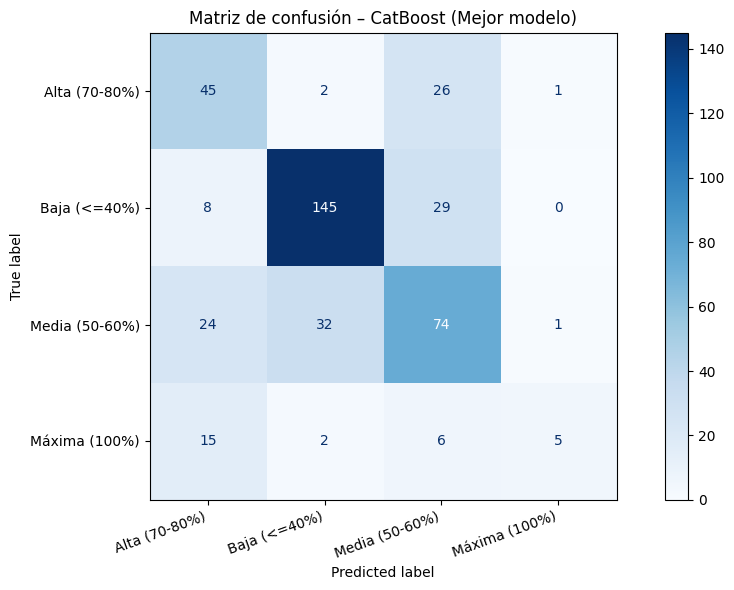

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matriz
cm = confusion_matrix(y_test_enc, y_pred_cat)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 6))  # ← más ancho
disp.plot(ax=ax, cmap="Blues", values_format='d')


plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.subplots_adjust(bottom=0.25)
plt.title("Matriz de confusión – CatBoost (Mejor modelo)")
plt.tight_layout()
plt.show()


# Aplicación de SMOTE y decisión sobre su uso

Para manejar el desbalance entre las categorías del porcentaje de beca, se probó la técnica SMOTE con el fin de aumentar artificialmente la representación de las clases minoritarias. Si bien esta técnica permite equilibrar el conjunto de entrenamiento, también puede introducir ruido y generar observaciones sintéticas que no reflejan adecuadamente los patrones reales del programa de becas.

En este caso, el uso de SMOTE no mejoró de manera consistente el desempeño de los modelos y, en algunos escenarios, incrementó la variabilidad entre clases. Por esta razón, y para evitar distorsiones en la estructura original del dato, no se adoptó la versión con SMOTE como modelo final.

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


In [ ]:
resultados_smote = []

for nombre, modelo in modelos.items():
    print(f"\n➡ Re-entrenando con SMOTE: {nombre}")

    if nombre == "CatBoost":

        continue

    smote_pipe = ImbPipeline([
        ("preprocess", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", modelo)
    ])

    smote_pipe.fit(X_train, y_train_enc)
    y_pred = smote_pipe.predict(X_test)

    resultados_smote.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test_enc, y_pred),
        "F1_macro": f1_score(y_test_enc, y_pred, average='macro'),
        "Precision_macro": precision_score(y_test_enc, y_pred, average='macro', zero_division=0),
        "Recall_macro": recall_score(y_test_enc, y_pred, average='macro', zero_division=0)
    })

df_smote_results = pd.DataFrame(resultados_smote).sort_values("F1_macro", ascending=False)
df_smote_results



➡ Re-entrenando con SMOTE: CatBoost

➡ Re-entrenando con SMOTE: XGBoost

➡ Re-entrenando con SMOTE: RandomForest

➡ Re-entrenando con SMOTE: GradientBoosting

➡ Re-entrenando con SMOTE: LogReg


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,Modelo,Accuracy,F1_macro,Precision_macro,Recall_macro
0,XGBoost,0.645783,0.553676,0.573498,0.550134
2,GradientBoosting,0.612048,0.549799,0.553866,0.548631
1,RandomForest,0.609639,0.520158,0.552379,0.517431
3,LogReg,0.556627,0.482304,0.477502,0.509621


# Optimización para CATBoost

Se hizo un balance de clases diferente para CatBoost considerando que no puede realizarse con SMOTE

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Clases ya codificadas (después de LabelEncoder)
classes = np.unique(y_train_enc)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc
)

class_weights = dict(zip(classes, weights))

print("Class Weights para CatBoost:", class_weights)


Class Weights para CatBoost: {np.int64(0): np.float64(1.391778523489933), np.int64(1): np.float64(0.5712809917355371), np.int64(2): np.float64(0.7915076335877863), np.int64(3): np.float64(3.7364864864864864)}


In [ ]:
from catboost import CatBoostClassifier, Pool

cat_model_weighted = CatBoostClassifier(
    loss_function="MultiClass",
    random_seed=42,
    verbose=False,
    class_weights=list(class_weights.values())  # 👈 clave
)

train_pool = Pool(X_train, y_train_enc, cat_features=cat_cols_idx)
test_pool = Pool(X_test, y_test_enc, cat_features=cat_cols_idx)

cat_model_weighted.fit(train_pool)

y_pred = cat_model_weighted.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("Accuracy:", accuracy_score(y_test_enc, y_pred))
print("F1_macro:", f1_score(y_test_enc, y_pred, average='macro'))
print(classification_report(y_test_enc, y_pred))


Accuracy: 0.6240963855421687
F1_macro: 0.5351220561190795
              precision    recall  f1-score   support

           0       0.49      0.64      0.56        74
           1       0.78      0.74      0.76       182
           2       0.53      0.54      0.54       131
           3       0.43      0.21      0.29        28

    accuracy                           0.62       415
   macro avg       0.56      0.53      0.54       415
weighted avg       0.63      0.62      0.62       415



In [ ]:
# Mejor modelo
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

best_xgb_smote = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        objective="multi:softmax",
        num_class=len(le.classes_),
        eval_metric="mlogloss",
        random_state=42
    ))
])

best_xgb_smote.fit(X_train, y_train_enc)

# Guardamos también las predicciones de test por si quieres revisar
y_pred_xgb_smote = best_xgb_smote.predict(X_test)

print(classification_report(y_test_enc, y_pred_xgb_smote))


              precision    recall  f1-score   support

           0       0.51      0.62      0.56        74
           1       0.78      0.80      0.79       182
           2       0.57      0.53      0.55       131
           3       0.44      0.25      0.32        28

    accuracy                           0.65       415
   macro avg       0.57      0.55      0.55       415
weighted avg       0.64      0.65      0.64       415



# **Modelo seleccionado**

Tras la comparación general, CatBoost presentó el mejor equilibrio entre desempeño, estabilidad y capacidad para manejar variables categóricas sin necesidad de transformaciones extensivas. Además, su comportamiento fue más robusto sin depender de datos sintéticos, lo que lo convierte en el modelo más adecuado para la clasificación del porcentaje de beca.

# **SHAP**
---
Para este modelo se utilizó una visualización SHAP multifeature, que permite analizar de manera conjunta cómo varias variables influyen en las predicciones. Este enfoque facilita observar la estabilidad, dispersión y consistencia del impacto de cada característica, sin entrar en interpretaciones detalladas. Su propósito en el notebook es complementar la transparencia del modelo y ofrecer una mirada rápida a cómo cambian las contribuciones de las variables cuando se evalúan de forma simultánea.


In [ ]:
best_xgb = best_xgb_smote



In [ ]:
best_xgb = best_estimator.named_steps["model"]


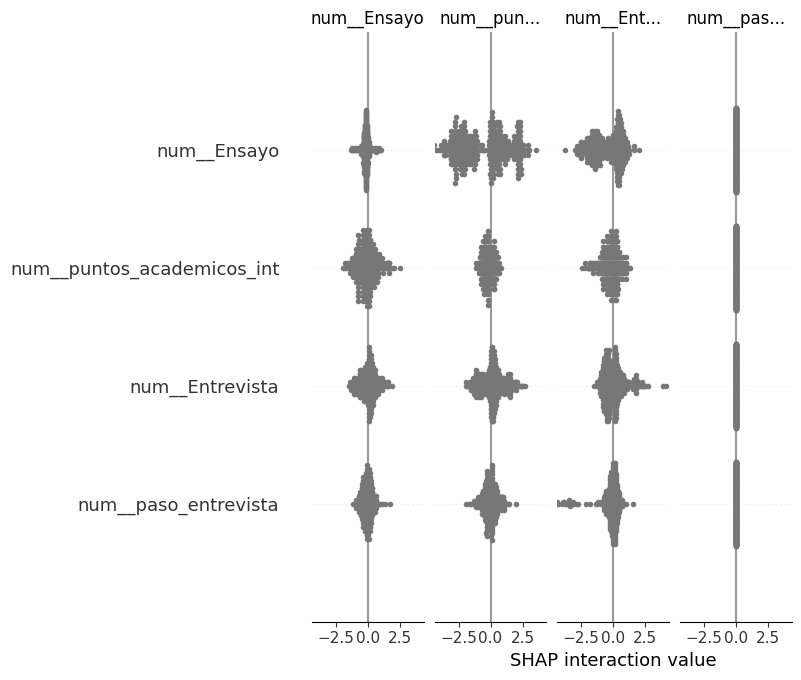

In [ ]:
import shap

shap.initjs()

# 1. Tomar el preprocesador y transformar X
preprocess_smote = best_xgb_smote.named_steps["preprocess"]
X_train_trans = preprocess_smote.fit_transform(X_train)
X_test_trans  = preprocess_smote.transform(X_test)

# 2. Sacar SOLO el modelo de XGBoost dentro del pipeline
xgb_model = best_xgb_smote.named_steps["model"]

# 3. Crear el explainer de árbol
explainer = shap.TreeExplainer(xgb_model)

# 4. Calcular valores SHAP en el conjunto de test transformado
shap_values = explainer.shap_values(X_test_trans)

# 5. Summary plot global
feature_names = preprocess_smote.get_feature_names_out()
shap.summary_plot(shap_values, X_test_trans, feature_names=feature_names)
